In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
plt.style.use("seaborn-v0_8-whitegrid") # Or "whitegrid"
sns.set_palette("viridis")

# Generate the colors
viridis_colors = cm.viridis(np.linspace(0, 1, 5))

# Use [] for indexing
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = "#800000"
neutral_color = viridis_colors[4]
customer_palette = viridis_colors

In [3]:
#reading the data
df = pd.read_csv("/content/88QepNHUHH9SnnVFrjM2J6.csv", encoding = "latin-1")

In [4]:
#performing EDA
print("rows and columns : ", df.shape)
print("Columns : ")
print(df.columns.tolist())
print("Duplicates :", df.duplicated().sum())
print("Missing values :")
print(df.isnull().sum().sort_values(ascending = False))


rows and columns :  (180519, 53)
Columns : 
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price'

In [5]:
#cleaning the data
columns_to_drop = [
    "Product Description",
    "Product Image",
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Order Zipcode",
    "Longitude",
    "Latitude",
    "Order Item Cardprod Id",
    "Order Item Id",
    "Order Item Discount",
    "Order Item Discount Rate",
    "Order Item Product Price",
    "Order Item Quantity",
    "Order Item Total",
    "Category Id",
    "Department Id",
    "Order Id",
    "Order Customer Id",
    "Customer Id",
    "Product Card Id",
    "Product Category Id",
    "Benefit per order",
    "Product Status",
    "Customer City",
    "Order City",
    "Order Country",
    "Order State",
    "Customer State",
    "Market"
]
#dropping the unnecessary columns
df = df.drop(columns = columns_to_drop)

In [6]:
#removing cancelled orders
df = df[df["Delivery Status"] != "Shipping canceled"]

In [7]:
#changing the datetime for the columns
for c in ["order date (DateOrders)", "shipping date (DateOrders)"]:
    df[c] = pd.to_datetime(df[c], errors = "coerce", dayfirst = False)

In [8]:
#checking afther cleaning
print("Rows and Columns : ", df.shape)
print("Missing values :")
print(df.isnull().sum().sort_values(ascending = False))

Rows and Columns :  (172765, 20)
Missing values :
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Department Name                  0
order date (DateOrders)          0
Order Item Profit Ratio          0
Sales                            0
Order Profit Per Order           0
Order Region                     0
Order Status                     0
Product Name                     0
Product Price                    0
shipping date (DateOrders)       0
Shipping Mode                    0
dtype: int64


In [9]:
#checking columns with low cardinality
for i in df.columns:
    if df[i].nunique() < 10:
        print("\n Column name : ",i)
        print("Value Counts", df[i].value_counts())


 Column name :  Type
Value Counts Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

 Column name :  Days for shipping (real)
Value Counts Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

 Column name :  Days for shipment (scheduled)
Value Counts Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

 Column name :  Delivery Status
Value Counts Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

 Column name :  Late_delivery_risk
Value Counts Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

 Column name :  Customer Country
Value Counts Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

 Column name :  Customer Segment
Value Counts Customer Segment
Consumer       89420
Corporate     

In [10]:
#order processing time and delay
df["Order Processing Time"] = (df["shipping date (DateOrders)"] - df["order date (DateOrders)"]).dt.days
df["Delays"] = df["Order Processing Time"] - df["Days for shipment (scheduled)"]
df["Is_Delayed"] = df["Delays"] > 0
df["order_month"] = df["order date (DateOrders)"].dt.month
df["order_day"] = df["order date (DateOrders)"].dt.day_name()
df["order_hour"] = df["order date (DateOrders)"].dt.hour


In [11]:
#profitability in order profit
df["profitability"] = np.where(df["Order Profit Per Order"] > 0, "Profit", np.where(df["Order Profit Per Order"] < 0, "Loss", "Break Even"))
df["profitability"].value_counts()

,count
profitability,
Profit,139354
Loss,32295
Break Even,1116


In [12]:
#profitability visuals
profit_counts = df["profitability"].value_counts(normalize = True)

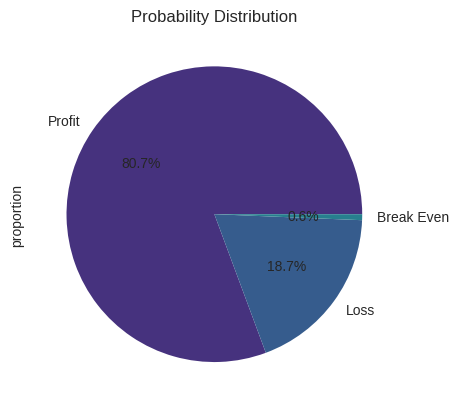

In [13]:
profit_counts.plot(kind = "pie", autopct = "%1.1f%%", color = [accent_color, danger_color, secondary_color])
plt.title("Probability Distribution")
plt.show()

In [14]:
#function to mark values
def format_value(value):
    if value >= 1e6:
        return f"${value/1e6:.1f}M"
    elif value >= 1e3:
        return f"${value/1e3:.1f}K"
    else:
        return f"${value:.0f}"


delayed_df = df[df["Delays"] > 0]
metrics = {}
metrics["total_orders"] = len(df)
metrics["late_deliveries"] = len(delayed_df)
metrics["90%_Delay_days"] = delayed_df["Delays"].quantile(0.90)
metrics["On_time_delivery %"] = (1 - float(metrics["late_deliveries"] / metrics["total_orders"])) * 100
metrics["Late Delivery %"] = float(metrics["late_deliveries"]) / metrics["total_orders"] * 100
metrics["total_profit"] = format_value(df.loc[df["Order Profit Per Order"] > 0, "Order Profit Per Order"].sum())
metrics["total_loss_due_to_delays"] = format_value(df.loc[df["Delays"] > 0, "Order Profit Per Order"].sum())

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")

total_orders: 172765
late_deliveries: 94523
90%_Delay_days: 3.00
On_time_delivery %: 45.29
Late Delivery %: 54.71
total_profit: $7.5M
total_loss_due_to_delays: $2.1M


In [15]:
#profit and loss in the delays
profit_delay = df.groupby('Delays')['Order Profit Per Order'].agg(
    mean_profit='mean',
    total_profit='sum',
    order_count='count'
).reset_index()

display(profit_delay)

,Delays,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [16]:
#delay distribution
delay_dist = (df["Delays"].value_counts(normalize = True).sort_values(ascending = True) * 100).reset_index()

In [17]:
delay_dist.columns = ["Delays_Days", "Delays_Percentage"]

In [18]:
#making the charts now
print("Profit Metrics by Delay Days")
display(profit_delay.round(1))

print("Delay Distribution")
display(delay_dist.round(1))

Profit Metrics by Delay Days


,Delays,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697


Delay Distribution


,Delays_Days,Delays_Percentage
0,4,3.9
1,3,3.9
2,-1,12.0
3,-2,12.1
4,2,15.9
5,0,21.2
6,1,31.0


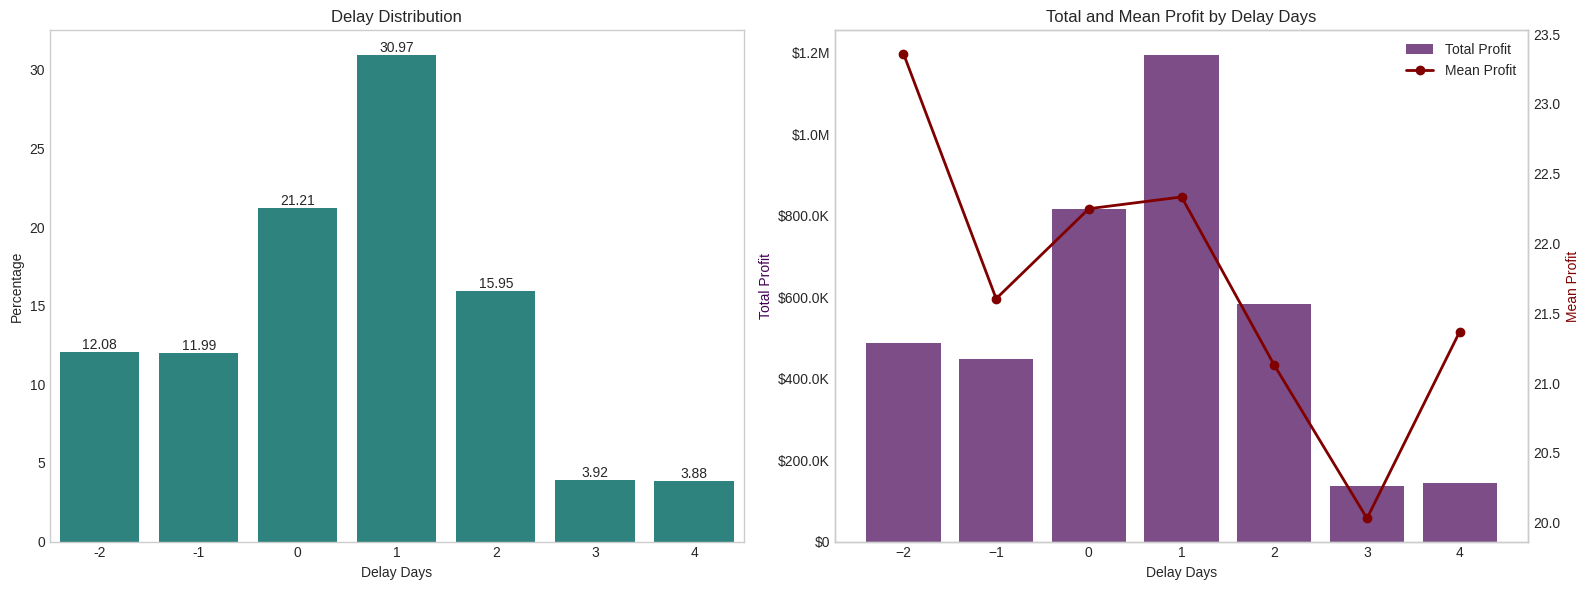

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16,6))

# First subplot: delay distribution
sns.barplot(data = delay_dist, x = "Delays_Days", y = "Delays_Percentage", ax = ax1, color = accent_color)
ax1.set_title("Delay Distribution")
ax1.set_xlabel("Delay Days")
ax1.set_ylabel("Percentage")
ax1.grid(False)

for bar in ax1.patches:
    ax1.annotate(format(bar.get_height(), '.2f'),(bar.get_x() + bar.get_width() / 2,bar.get_height()),
                 ha = 'center', va = 'bottom')

# Second subplot: Total Profit (Bars)
ax2.bar(profit_delay["Delays"], profit_delay["total_profit"], color = primary_color, alpha=0.7, label="Total Profit")
ax2.set_title("Total and Mean Profit by Delay Days")
ax2.set_xlabel("Delay Days")
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.grid(False)

# Create a secondary y-axis for Mean Profit (Line)
ax3 = ax2.twinx()
ax3.plot(profit_delay["Delays"], profit_delay["mean_profit"], color=danger_color, marker='o', linewidth=2, label="Mean Profit")
ax3.set_ylabel("Mean Profit", color=danger_color)
ax3.grid(False)

# Combine legends
lines, labels = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

def format_fun(values, tick_number):
  if values >= 1e6:
    return f"${values/1e6:.1f}M"
  elif values >= 1e3:
    return f"${values/1e3:.1f}K"
  else:
    return f"${values:.0f}"

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_fun))


plt.tight_layout()
plt.show()

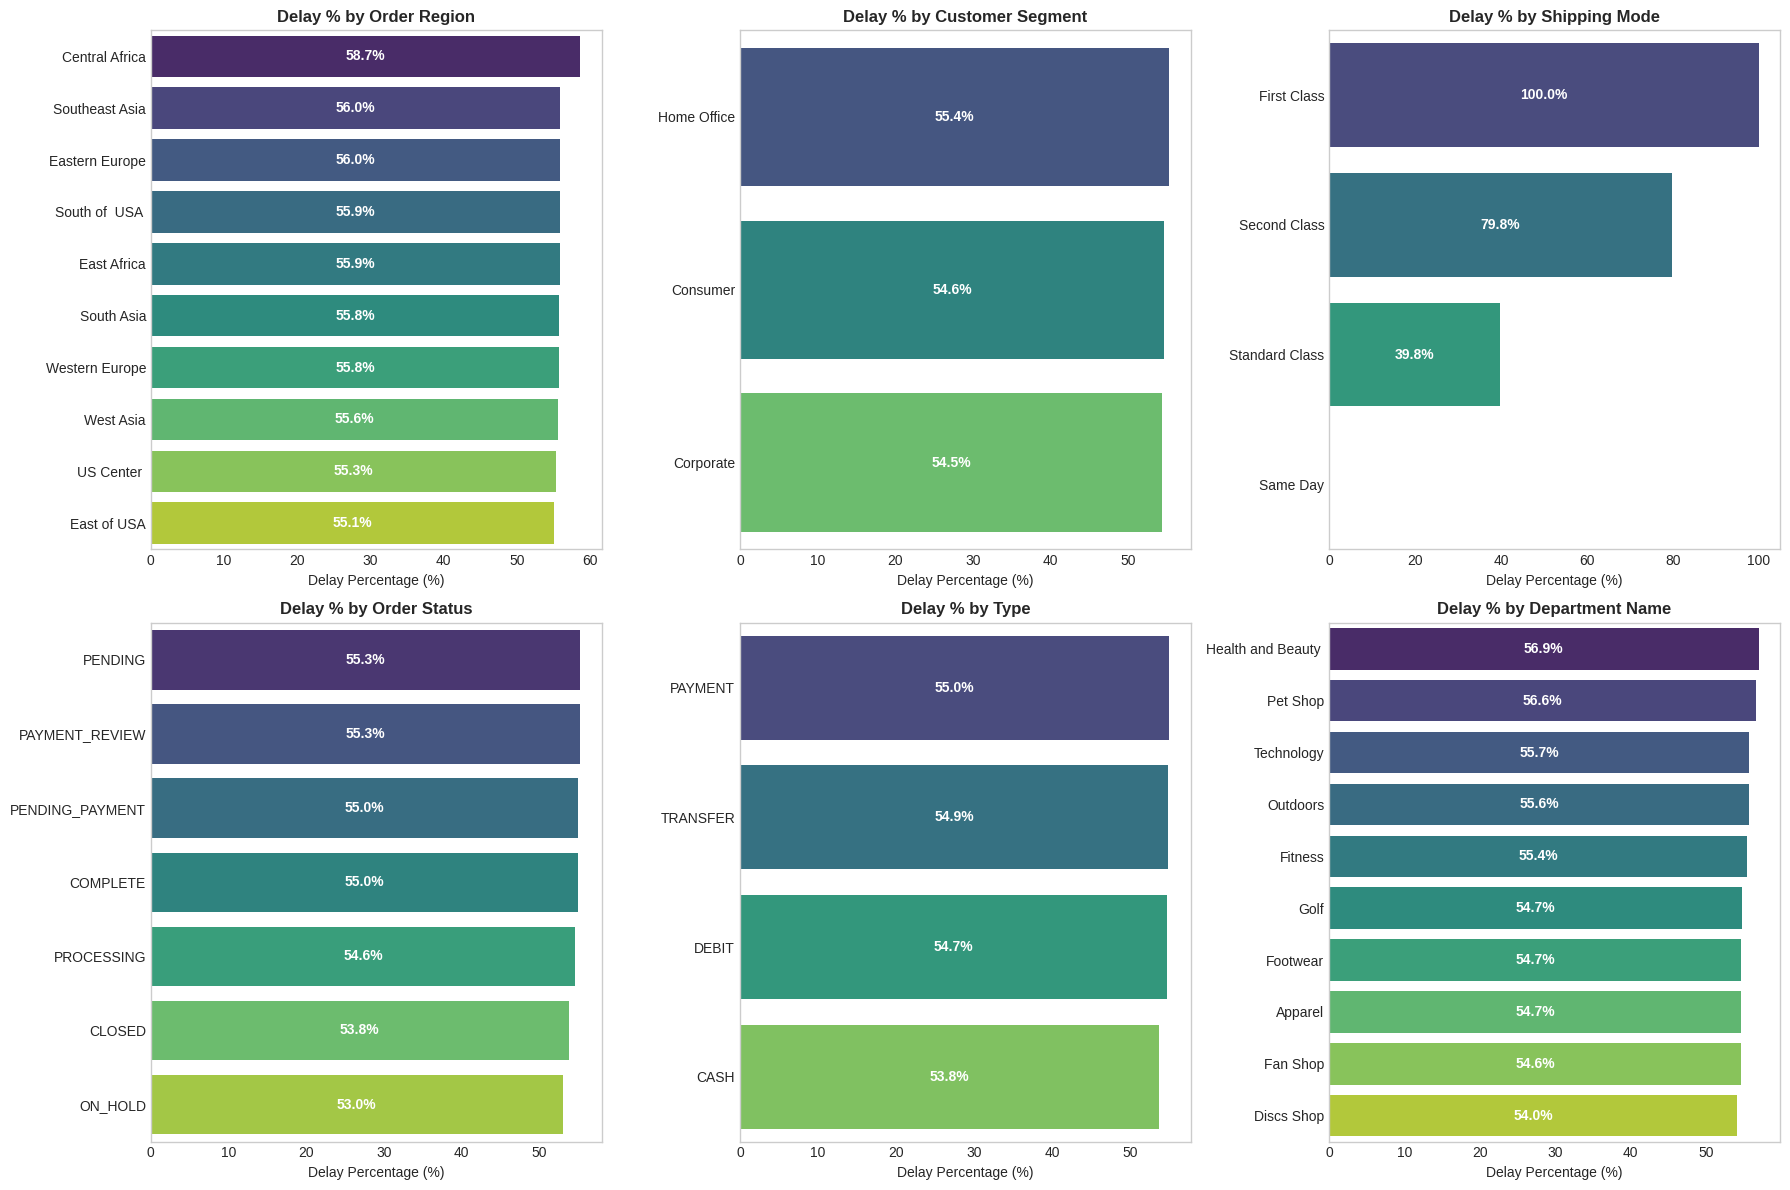

In [20]:
def category_delay(category):
  cat_df = df.groupby(category).agg(
      total_orders = ("Delays", "count"),
      late_orders = ("Is_Delayed", "sum")
  ).reset_index()

  cat_df["delay_percentage"] = cat_df["late_orders"] / cat_df["total_orders"] * 100
  cat_df = cat_df.sort_values(by = "delay_percentage", ascending = False).head(10)

  return cat_df

category_list = ["Order Region", "Customer Segment", "Shipping Mode", "Order Status", "Type", "Department Name"]

fig, axes = plt.subplots(2, 3, figsize = (18, 12))
axes = axes.flatten()

for ax, cat_name in zip(axes, category_list):
  cat_df = category_delay(cat_name)
  sns.barplot(data = cat_df, x = "delay_percentage", y = cat_name, ax = ax, palette = "viridis")
  ax.set_title(f"Delay % by {cat_name}", fontsize=12, fontweight='bold')
  ax.set_xlabel("Delay Percentage (%)")
  ax.set_ylabel("")
  ax.grid(False)

  # Adding the percentage labels ON the bars
  for p in ax.patches:
    width = p.get_width()
    if width > 0: # Ensure there is a bar to label
        ax.annotate(f'{width:.1f}%',
                    (width / 2, p.get_y() + p.get_height() / 2),
                    ha = 'center', va = 'center',
                    color = 'white', fontweight = 'bold')

plt.tight_layout()
plt.show()

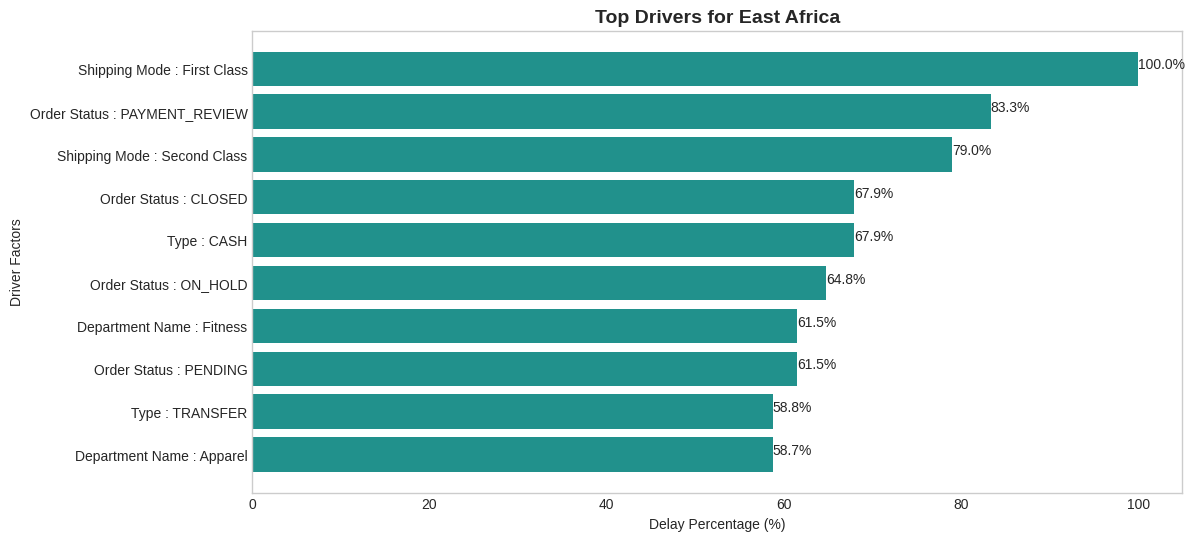

In [21]:
#root cause analysis
def top_drivers_for_region(region):
  df_region = df[df["Order Region"] == region].copy()

  drivers = ["Shipping Mode", "Customer Segment", "Department Name", "Type", "Order Status"]

  all_factors = []
  for driver in drivers:
    driver_df = df_region.groupby(driver).agg(
        total_orders = ("Delays", "count"),
        late_orders = ("Is_Delayed", "sum"),
        avg_delay_days = ("Delays", "mean")
    ).reset_index()

    driver_df["delay_percentage"] = driver_df["late_orders"] / driver_df["total_orders"] * 100
    driver_df["driver"] = driver
    driver_df["factor_level"] = driver + " : " + driver_df[driver].astype(str)

    all_factors.append(driver_df[["driver", "factor_level", "delay_percentage", "avg_delay_days", "total_orders"]])

  final_df = pd.concat(all_factors)

  # Get top 10 drivers overall
  top_factors = final_df.sort_values(by = "delay_percentage", ascending = False).head(10).copy()

  # Specific logic to ensure 'Shipping Mode : First Class' is at the top if it exists in data
  # We add a temporary sort key to put our target at the very end (top of horizontal bar)
  top_factors['sort_priority'] = top_factors['factor_level'].apply(lambda x: 1 if 'First Class' in x else 0)
  top_factors = top_factors.sort_values(by=['sort_priority', 'delay_percentage'], ascending=[True, True])

  plt.figure(figsize = (12, 6))

  plt.barh(top_factors["factor_level"], top_factors["delay_percentage"], color = accent_color)
  plt.xlabel("Delay Percentage (%)")
  plt.ylabel("Driver Factors")
  plt.title(f"Top Drivers for {region}", fontsize = 14, fontweight = "bold")
  plt.grid(False)

  for bar in plt.gca().patches:
    plt.gca().annotate(f'{bar.get_width():.1f}%',
                       (bar.get_width(), bar.get_y() + bar.get_height() / 2))

  plt.show()

top_drivers_for_region("East Africa")

In [22]:
# Grouping by month to analyze seasonal trends in delays
seasonal_delay = df.groupby('order_month').agg(
    total_orders=('Is_Delayed', 'count'),
    late_orders=('Is_Delayed', 'sum'),
    avg_delay_days=('Delays', 'mean')
).reset_index()

seasonal_delay['delay_percentage'] = (seasonal_delay['late_orders'] / seasonal_delay['total_orders']) * 100

print("Monthly Delay Metrics:")
display(seasonal_delay.round(2))

Monthly Delay Metrics:


,order_month,total_orders,late_orders,avg_delay_days,delay_percentage
0,1,17289,9380,0.54,54.25
1,2,13845,7560,0.56,54.60
2,3,15293,8382,0.54,54.81
3,4,14775,8053,0.54,54.50
4,5,15166,8341,0.54,55.00
5,6,14482,7931,0.54,54.76
6,7,15170,8151,0.52,53.73
7,8,15305,8477,0.55,55.39
8,9,14828,8213,0.54,55.39
9,10,12448,6734,0.52,54.10


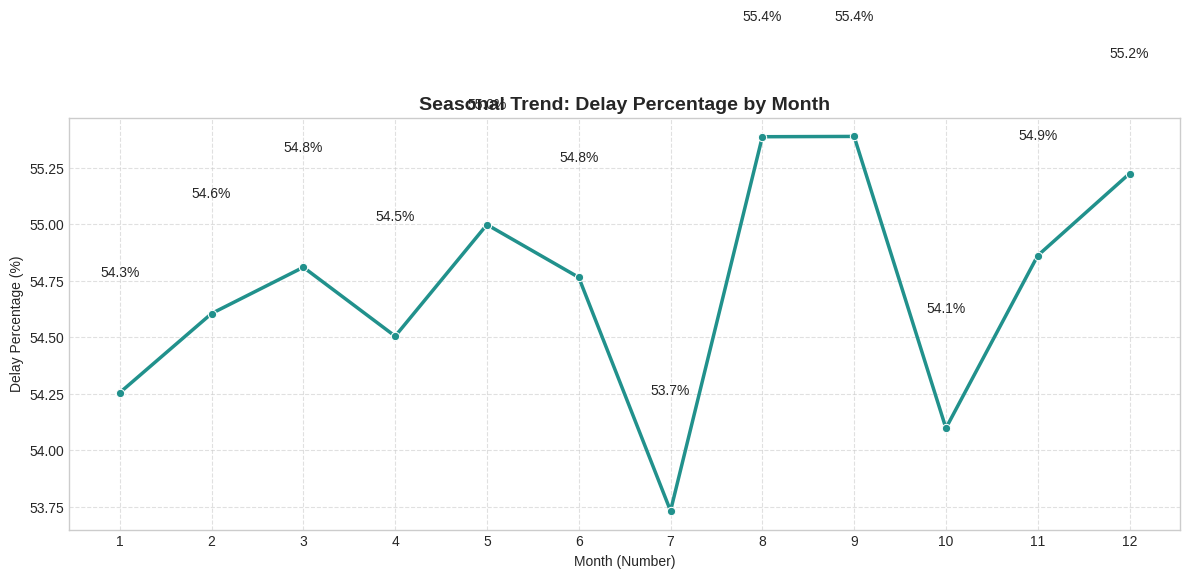

In [23]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=seasonal_delay, x='order_month', y='delay_percentage', marker='o', color=accent_color, linewidth=2.5)

plt.title('Seasonal Trend: Delay Percentage by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month (Number)')
plt.ylabel('Delay Percentage (%)')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.6)

# Adding labels to points
for x, y in zip(seasonal_delay['order_month'], seasonal_delay['delay_percentage']):
    plt.text(x, y + 0.5, f'{y:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

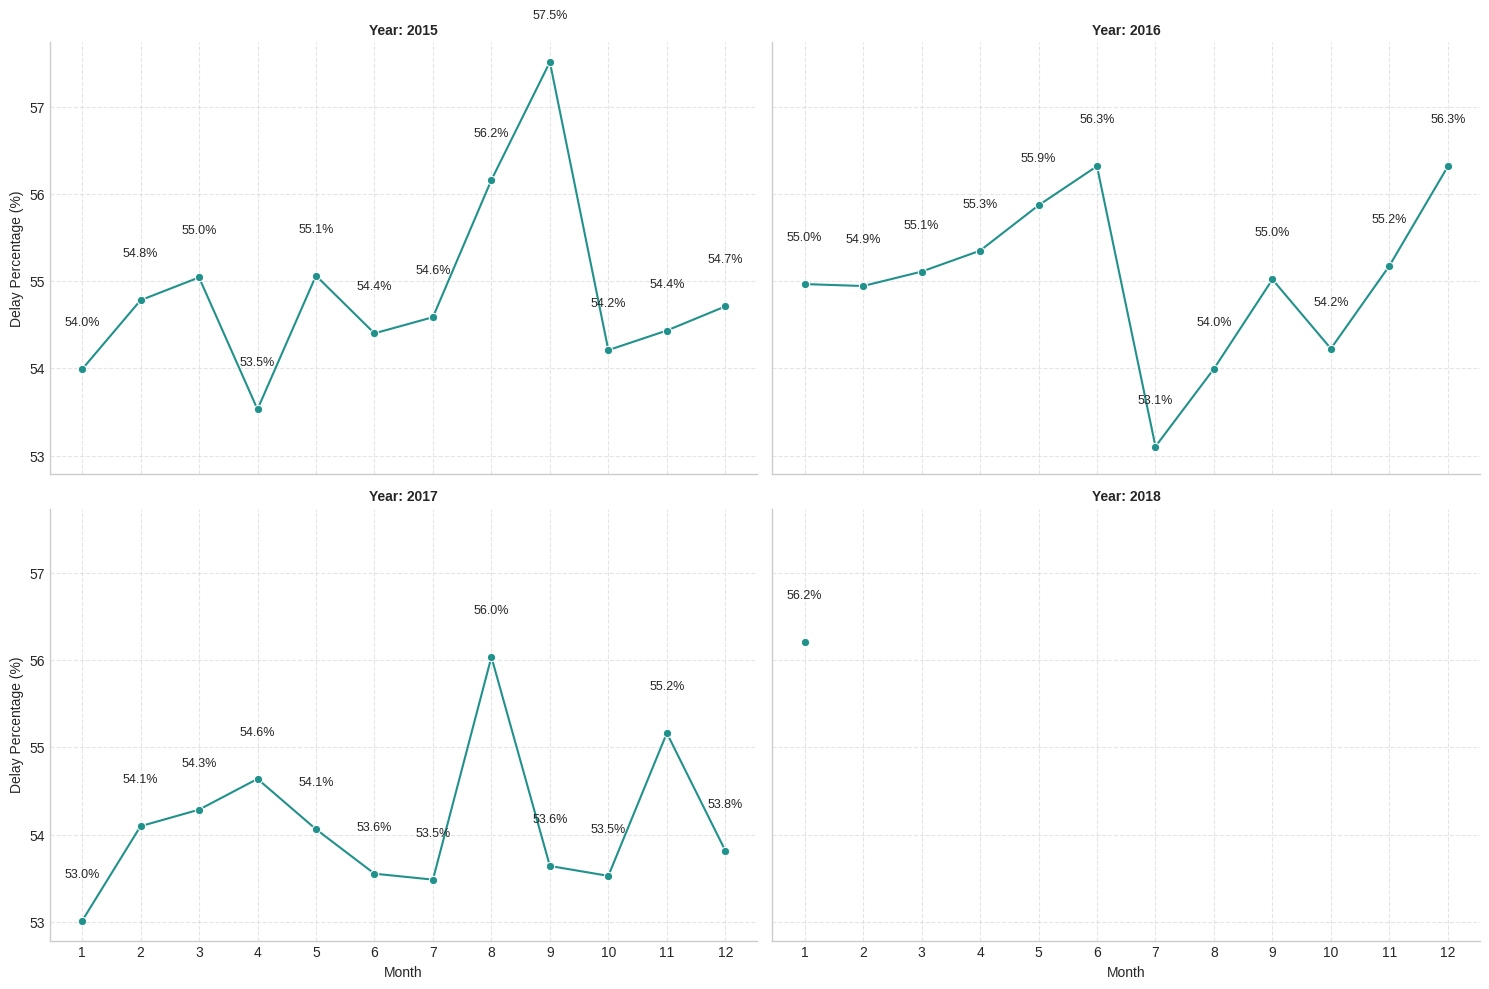

In [24]:
# Extracting year and grouping by Year and Month
df['order_year'] = df['order date (DateOrders)'].dt.year

yearly_monthly_delay = df.groupby(['order_year', 'order_month']).agg(
    total_orders=('Is_Delayed', 'count'),
    late_orders=('Is_Delayed', 'sum')
).reset_index()

yearly_monthly_delay['delay_percentage'] = (yearly_monthly_delay['late_orders'] / yearly_monthly_delay['total_orders']) * 100

# Faceted Plot for Yearly Trends
g = sns.FacetGrid(yearly_monthly_delay, col='order_year', col_wrap=2, height=5, aspect=1.5, sharey=True)
g.map(sns.lineplot, 'order_month', 'delay_percentage', marker='o', color=accent_color)

g.set_titles("Year: {col_name}", fontweight='bold')
g.set_axis_labels("Month", "Delay Percentage (%)")

for ax in g.axes.flatten():
    ax.set_xticks(range(1, 13))
    ax.grid(True, linestyle='--', alpha=0.5)
    # Adding labels to each point
    data = yearly_monthly_delay[yearly_monthly_delay['order_year'] == int(ax.get_title().split(': ')[1])]
    for x, y in zip(data['order_month'], data['delay_percentage']):
        ax.text(x, y + 0.5, f'{y:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [25]:
#now we analyze with hour, days, month
delay_month = df.groupby('order_month').agg(
    total_orders=('Is_Delayed', 'count'),
    late_orders=('Is_Delayed', 'sum')
).reset_index()

delay_month['delay_percentage'] = (delay_month['late_orders'] / delay_month['total_orders']) * 100

delay_day = df.groupby('order_day').agg(
    total_orders=('Is_Delayed', 'count'),
    late_orders = ("Is_Delayed", "sum")
).reset_index()

delay_day['delay_percentage'] = (delay_day['late_orders'] / delay_day['total_orders']) * 100

delay_hour = df.groupby("order_hour").agg(
    total_orders = ("Is_Delayed", "count"),
    late_orders = ("Is_Delayed", "sum")
).reset_index()

delay_hour["delay_percentage"] = (delay_hour["late_orders"] / delay_hour["total_orders"]) * 100

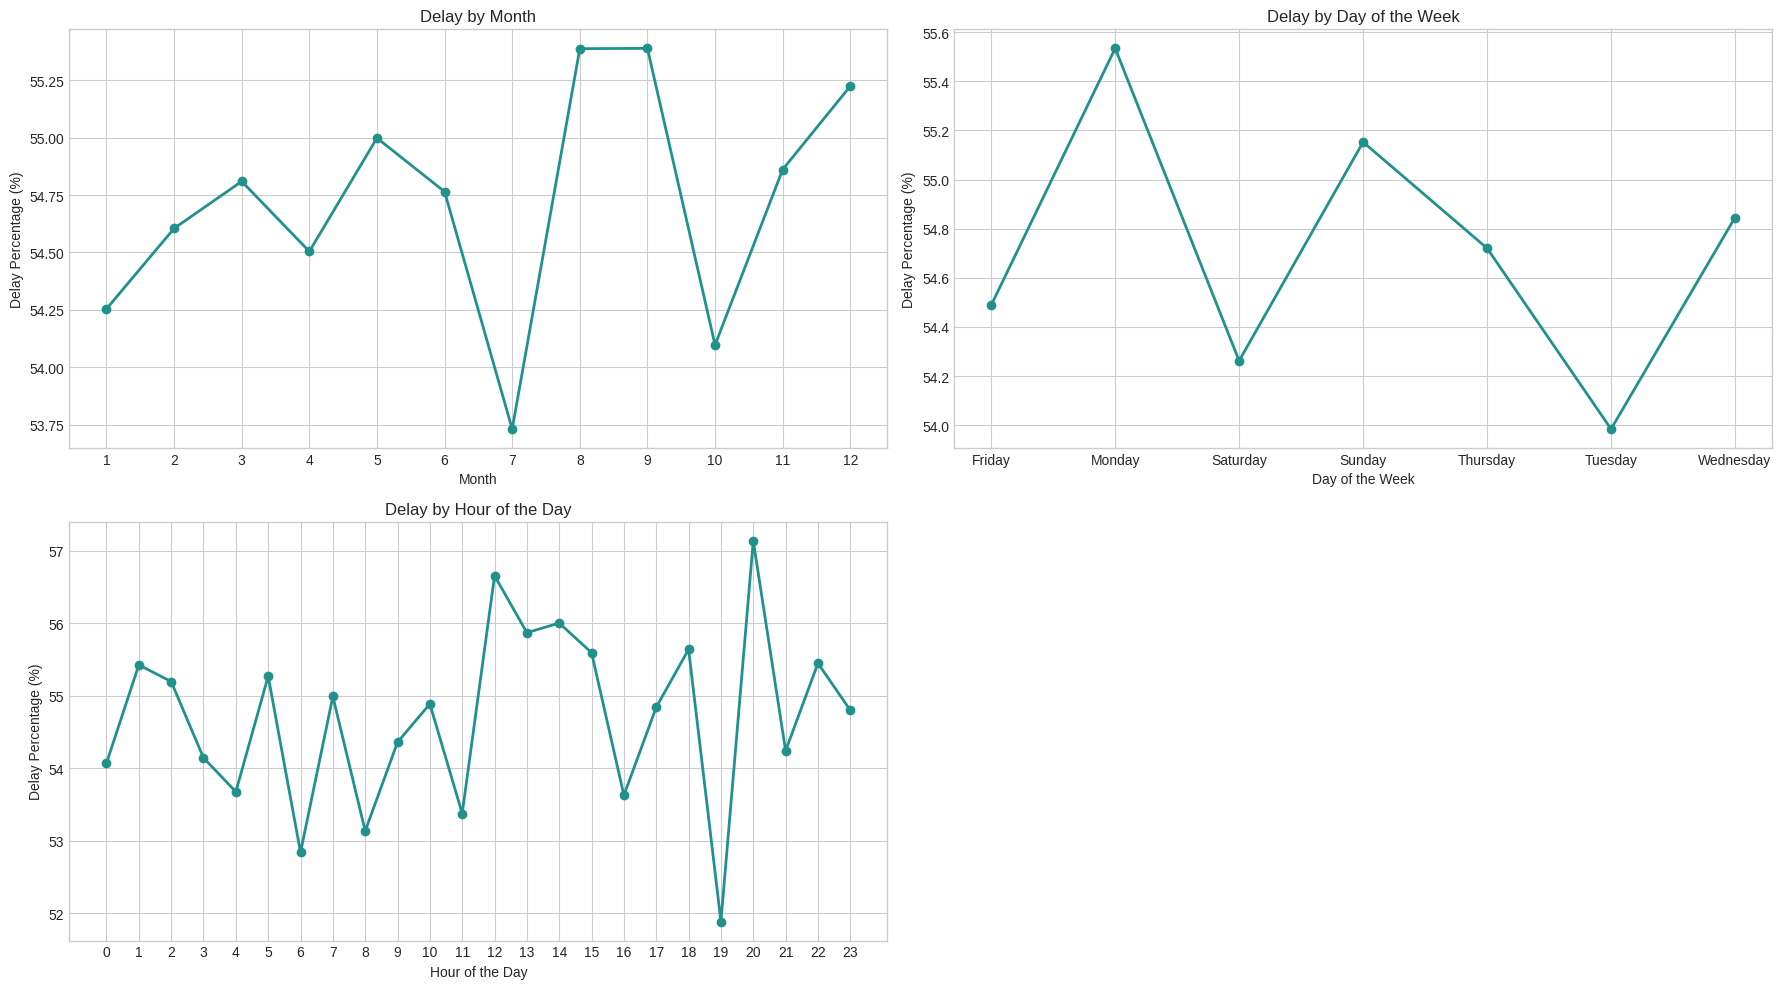

In [26]:
fig, axes = plt.subplots(2, 2, figsize = (18, 10))
axes = axes.flatten()
ax1, ax2, ax3, ax4 = axes

# Subplot 1: Month
ax1.plot(delay_month["order_month"], delay_month["delay_percentage"], marker = "o", color = accent_color, linewidth = 2)
ax1.set_title("Delay by Month")
ax1.set_xticks(delay_month["order_month"])
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")

# Subplot 2: Day of Week
ax2.plot(delay_day["order_day"], delay_day["delay_percentage"], marker = "o", color = accent_color, linewidth = 2)
ax2.set_title("Delay by Day of the Week")
ax2.set_xlabel("Day of the Week")
ax2.set_ylabel("Delay Percentage (%)")

# Subplot 3: Hour of Day
ax3.plot(delay_hour["order_hour"], delay_hour["delay_percentage"], marker = "o", color = accent_color, linewidth = 2)
ax3.set_title("Delay by Hour of the Day")
ax3.set_xlabel("Hour of the Day")
ax3.set_xticks(delay_hour["order_hour"])
ax3.set_ylabel("Delay Percentage (%)")

# Hide the unused 4th subplot
ax4.axis('off')

plt.tight_layout()
plt.show()

In [28]:
#predictive modeling

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [30]:
# selecting features for the model
x = df[["Type", "Days for shipment (scheduled)", "Category Name", "Customer Segment", "Department Name", "Order Region", "Shipping Mode", "order_month", "order_hour"]]
y = df["Late_delivery_risk"]

In [35]:
cat_col = x.select_dtypes(include = ["object", "category"]).columns.tolist()

print("Categorical Columns:")
print(cat_col)

#frequency encoding for high cardinality columns
for col in cat_col:
  freq = x[col].value_counts(normalize = True)
  x[f"{col}_freq"] = x[col].map(freq)

x_encoded = x.drop(cat_col, axis = 1)
print("Features after Encoding:")
print(x_encoded.shape)

x = x_encoded.copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

Categorical Columns:
[]
Features after Encoding:
(172765, 9)


In [37]:
y.value_counts()

,count
Late_delivery_risk,
1,98977
0,73788


In [39]:
#using smote to counter balance the weight
print("before balancing the data", Counter(y_train))
smote = SMOTE(random_state = 42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

print("After balancing the data", Counter(y_train_smote))

before balancing the data Counter({1: 79182, 0: 59030})
After balancing the data Counter({0: 79182, 1: 79182})


In [43]:
#evaluation function
def evaluation_mode(y_test, y_pred, model_name):
  print(f"{model_name} Metrics:")
  print("Accuracy Score:", accuracy_score(y_test, y_pred))
  print("Precision Score:", precision_score(y_test, y_pred))
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred))
  print("Classification Report:")
  print(classification_report(y_test, y_pred))

In [44]:
#now training begins
model = RandomForestClassifier(n_estimators = 100, random_state = 42)
model.fit(x_train_smote, y_train_smote)

y_pred = model.predict(x_test)

evaluation_mode(y_test, y_pred, RandomForestClassifier)

<class 'sklearn.ensemble._forest.RandomForestClassifier'> Metrics:
Accuracy Score: 0.7375047029201517
Precision Score: 0.7852241902026488
Confusion Matrix:
[[10720  4038]
 [ 5032 14763]]
Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.73     34553
weighted avg       0.74      0.74      0.74     34553

